## **1 - Setup & Imports**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings, re

import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from collections import Counter
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5),
                     'axes.spines.top':False,'axes.spines.right':False})
print('Libraries loaded!')

import sys, os
sys.path.append('..')
sys.path.append('.')

Libraries loaded!


## **2 - Generate & Load Dataset**

In [ ]:
import subprocess
result = subprocess.run(
    ['python', 'data_generator.py'],   
    capture_output=True, text=True
)
print(result.stdout or result.stderr)

âœ… Dataset saved to 'data\grievances_dataset.csv'
   Rows            : 3,000
   Columns         : ['complaint_id', 'date', 'complaint_text', 'department', 'sentiment', 'city', 'priority_level', 'resolution_days', 'is_repeat_complaint', 'submission_channel']
   Departments     : ['Healthcare', 'Water', 'Education', 'Electricity', 'Roads', 'Transport', 'Sanitation']
   Sentiments      : {'Negative': 1405, 'Neutral': 853, 'Critical/Urgent': 650, 'Positive': 92}
   Cities          : 8 cities



#### load dataset..

In [11]:
df_raw = pd.read_csv('data/grievances_dataset.csv')
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
df_raw.head(3)

Shape: (3000, 10)
Columns: ['complaint_id', 'date', 'complaint_text', 'department', 'sentiment', 'city', 'priority_level', 'resolution_days', 'is_repeat_complaint', 'submission_channel']


,complaint_id,date,complaint_text,department,sentiment,city,priority_level,resolution_days,is_repeat_complaint,submission_channel
0,CMP00001,2022-04-15,Medicines not available at government dispensa...,Healthcare,Negative,Mumbai,3,38,1,online
1,CMP00002,2023-10-28,The water coming from the tap is extremely dir...,Water,Negative,Ahmedabad,3,15,1,app
2,CMP00003,2022-12-15,Government school has no teachers for 26 month...,Education,Critical/Urgent,Chennai,5,3,0,app


## **3 - Data Quality Checks**

In [12]:
print('=== Missing Values ===')
print(df_raw.isnull().sum())
print('\n=== Duplicates:', df_raw.duplicated().sum())
print('\n=== Describe:')
df_raw.describe()

=== Missing Values ===
complaint_id           0
date                   0
complaint_text         0
department             0
sentiment              0
city                   0
priority_level         0
resolution_days        0
is_repeat_complaint    0
submission_channel     0
dtype: int64

=== Duplicates: 0

=== Describe:


,priority_level,resolution_days,is_repeat_complaint
count,3000.000000,3000.000000,3000.000000
mean,3.318333,19.076000,0.264000
std,1.184679,13.562652,0.440873
min,1.000000,1.000000,0.000000
25%,2.000000,7.000000,0.000000
50%,3.000000,16.000000,0.000000
75%,4.000000,31.000000,1.000000
max,5.000000,45.000000,1.000000


#### Complaints by Department & Sentiment (Distribution)

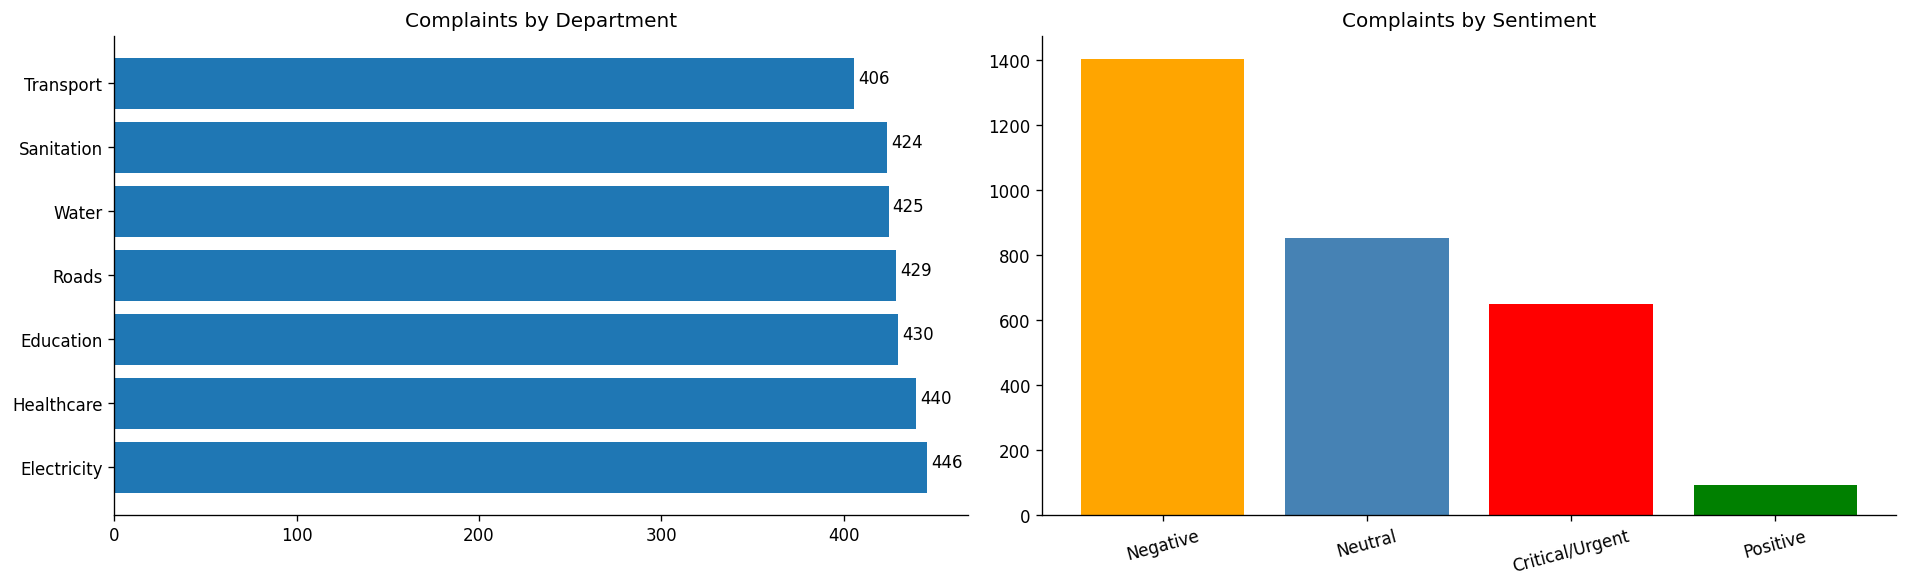

In [ ]:
import os
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(16,5))

#  Plot 1: Department Distribution
plt.subplot(1,2,1)
dept_counts = df_raw['department'].value_counts()
plt.barh(dept_counts.index, dept_counts.values)

# Show values
for i, v in enumerate(dept_counts.values):
    plt.text(v+2, i, str(v))

plt.title("Complaints by Department")


#  Plot 2: Sentiment Distribution
plt.subplot(1,2,2)
sent_counts = df_raw['sentiment'].value_counts()
cols=["orange","steelblue","red","green"]
plt.bar(sent_counts.index, sent_counts.values,color=cols[:len(sent_counts)])
plt.title("Complaints by Sentiment")
plt.xticks(rotation=15)
# Layout
plt.tight_layout()

# Save
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/01_class_distribution.png')

plt.show()

## **4 - Text Preprocessing**

In [ ]:
'''Raw Text
   ↓  clean_text()
Lowercase + No URLs + No symbols
   ↓  remove_stopwords()
No common useless words
   ↓  lemmatize_text()
All words in root form
   ↓
Ready for TF-IDF & ML Model '''

It cleans raw citizen complaint text step by step — from messy raw text to clean processed text ready for ML model.

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Stopwords
stop_words = set(stopwords.words('english'))

# Keep important words
important_words = ['not', 'no', 'never', 'urgent', 'emergency', 'immediately']
for word in important_words:
    stop_words.discard(word)

# Lemmatizer
lemmatizer = WordNetLemmatizer()

#  Clean text
def clean_text(text):

    if type(text) != str:
        return ''

    # lowercase
    text = text.lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove special characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

#  Remove stopwords
def remove_stopwords(text):
    words = text.split()
    clean_words = [word for word in words if word not in stop_words]
    return ' '.join(clean_words)

#  Lemmatization
def lemmatize_text(text):
    words = text.split()
    lemma_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemma_words)

#  Full preprocessing
def full_preprocess(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

# Example
sample = df_raw['complaint_text'].iloc[0]
print("Original :", sample)
print("Cleaned  :", clean_text(sample))
print("Processed:", full_preprocess(sample))

Original : Medicines not available at government dispensary for 2 weeks. Patients suffering badly.
Cleaned  : medicines not available at government dispensary for weeks patients suffering badly
Processed: medicine not available government dispensary week patient suffering badly


#### Apply preprocessing

####  Feature Engineering :

#####  `token_count`

Counts the number of words present in each complaint.

This helps analyze complaint length and text complexity.

#####  `has_urgent_word`

Checks whether the complaint contains important urgency-related words such as:

* `urgent`
* `emergency`
* `critical`
* `danger`

##### Returns:

* `1` → Urgent complaint detected
* `0` → Normal complaint

This feature helps the model identify high-priority complaints.

#####  `exclamation_count`

Counts how many `!` symbols are present in the complaint text.

This can act as an emotional or urgency indicator in sentiment analysis.

---


In [ ]:
print("Applying preprocessing to all complaints...")
df_raw['cleaned_text'] = df_raw['complaint_text'].apply(clean_text)
df_raw['processed_text'] = df_raw['cleaned_text'].apply(remove_stopwords)
df_raw['lemmatized_text'] = df_raw['processed_text'].apply(lemmatize_text)

# Count words
df_raw['token_count'] = df_raw['cleaned_text'].apply(lambda text: len(text.split()))

# Check urgent words
urgent_words = 'urgent|emergency|immediate|critical|danger'

df_raw['has_urgent_word'] = df_raw['complaint_text'] \
    .str.lower() \
    .str.contains(urgent_words, regex=True) \
    .astype(int)

# Count exclamation marks
df_raw['exclamation_count'] = df_raw['complaint_text'].apply(lambda text: str(text).count('!'))

print("Preprocessing complete!")
print("Avg tokens :", round(df_raw['token_count'].mean(), 1))
print("Urgent complaints :", df_raw['has_urgent_word'].sum())

Applying preprocessing to all complaints...
Preprocessing complete!
Avg tokens : 13.1
Urgent complaints : 501


## **5 - Word Cloud**

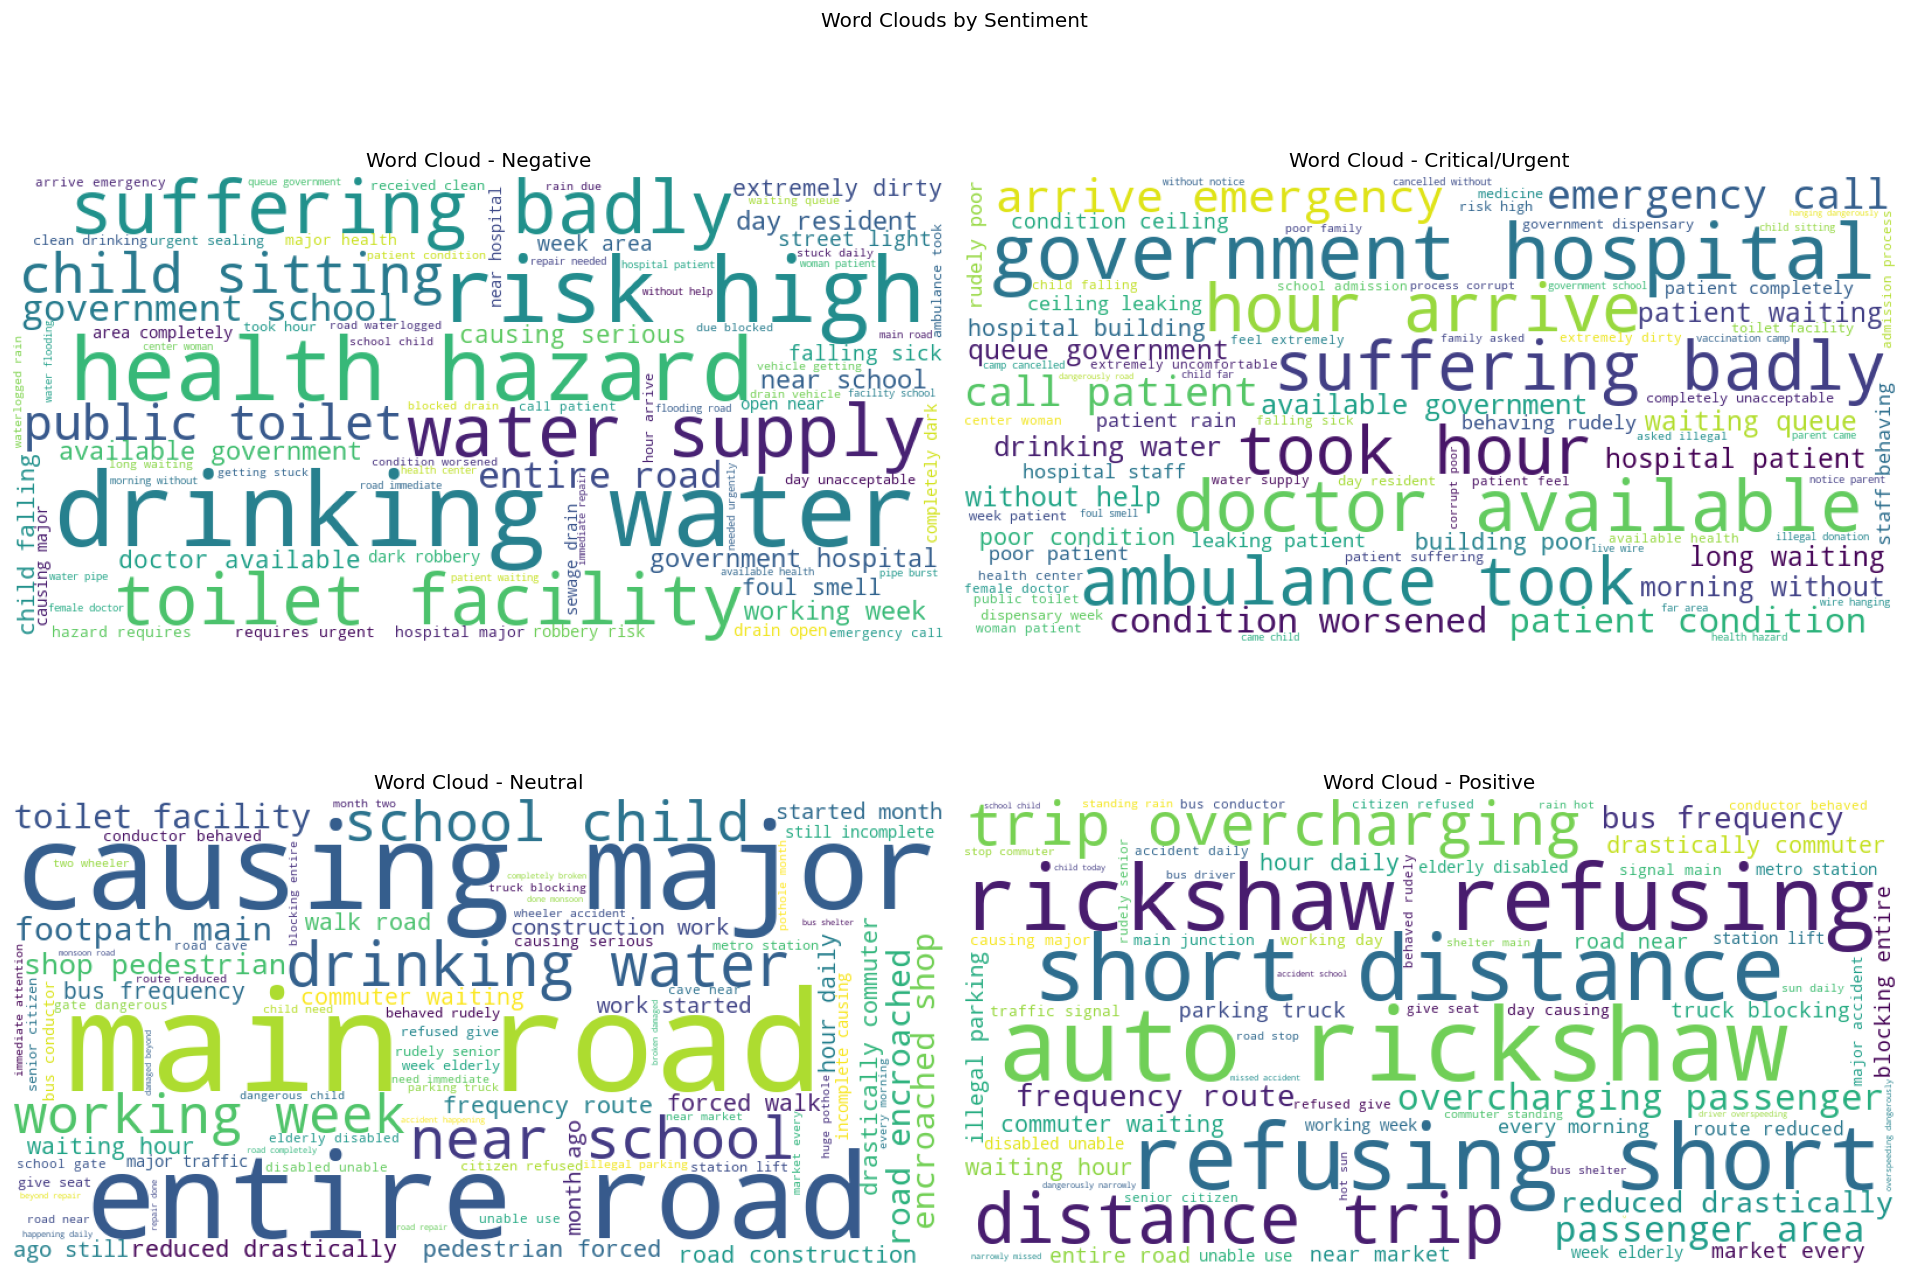

In [ ]:
try:
    from wordcloud import WordCloud

    plt.figure(figsize=(16,12))
    sentiments = ['Negative', 'Critical/Urgent', 'Neutral', 'Positive']

    for i, sentiment in enumerate(sentiments, 1):
        plt.subplot(2,2,i)

        # Filter sentiment data
        temp_df = df_raw[df_raw['sentiment'] == sentiment]
        if len(temp_df) == 0:
            plt.text(0.5, 0.5, 'No Data', ha='center')
            plt.axis('off')
            continue

        # Combine all text
        text = ' '.join(temp_df['lemmatized_text'])

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            max_words=80
        ).generate(text)

        plt.imshow(wc)
        plt.title(f'Word Cloud - {sentiment}')
        plt.axis('off')

    plt.suptitle("Word Clouds by Sentiment")
    plt.tight_layout()
    plt.savefig('reports/02_wordclouds.png')
    plt.show()

except ImportError:
    print("Run: pip install wordcloud")
    from collections import Counter
    words = ' '.join(df_raw['lemmatized_text']).split()
    print(Counter(words).most_common(20))

## **6 - N-gram Frequency Analysis**

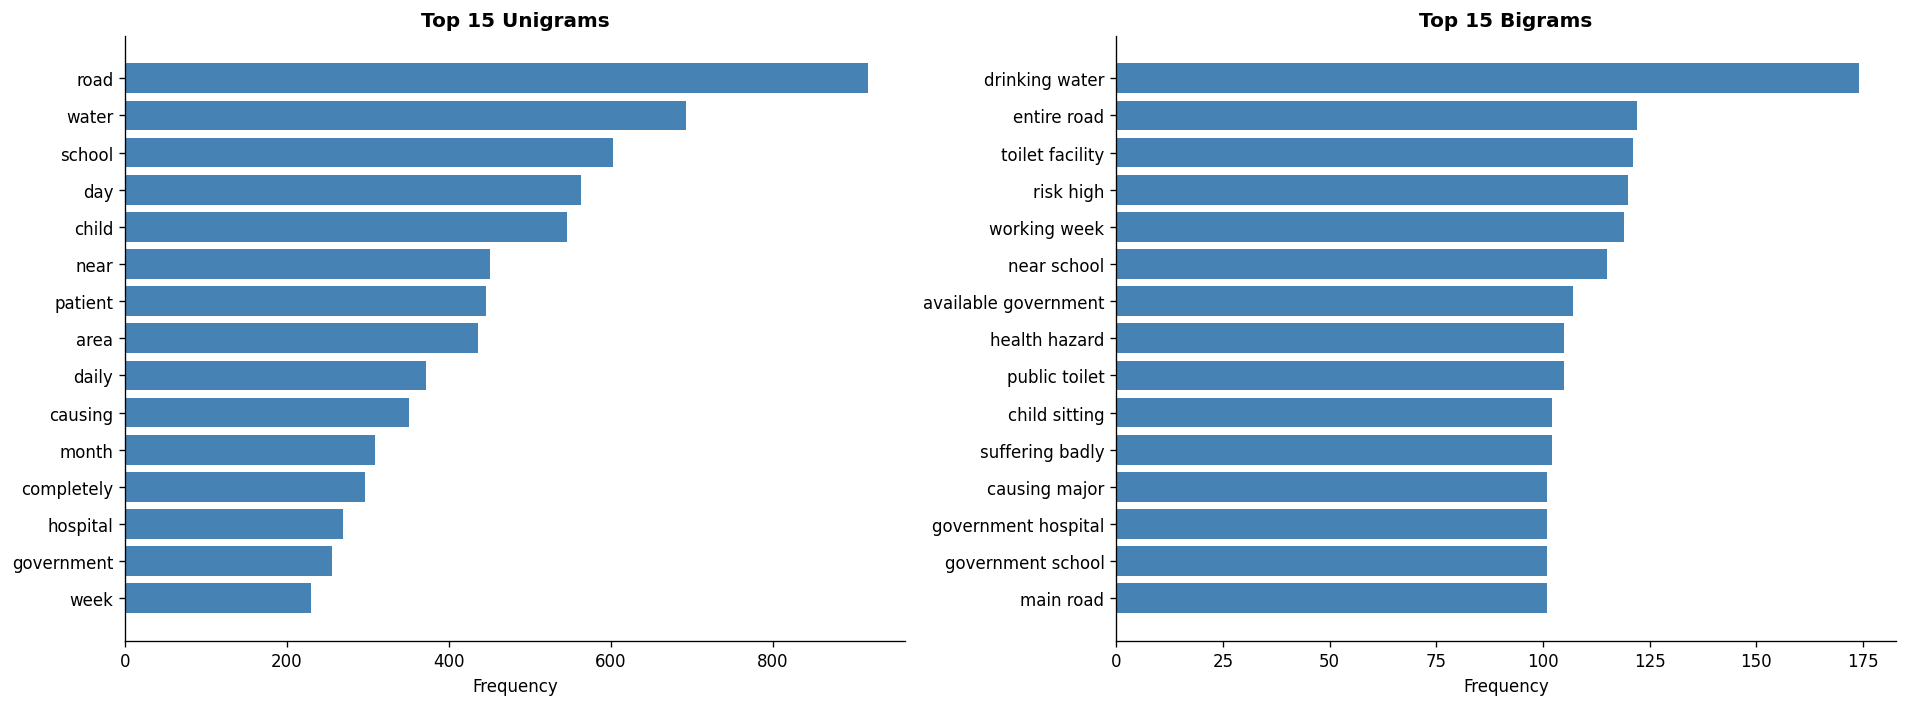

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (n, label) in zip(axes, [(1,'Top 15 Unigrams'),(2,'Top 15 Bigrams')]):
    vec = CountVectorizer(ngram_range=(n,n), max_features=15, stop_words='english')
    X   = vec.fit_transform(df_raw['lemmatized_text'])

    freqs = dict(zip(vec.get_feature_names_out(), X.toarray().sum(axis=0)))
    sorted_f = sorted(freqs.items(), key=lambda x: x[1], reverse=True)
    terms, counts = zip(*sorted_f)

    ax.barh(list(terms)[::-1], list(counts)[::-1], color='steelblue')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('reports/03_ngram_frequency.png', bbox_inches='tight')
plt.show()

## **7 - Extra Column Analysis**

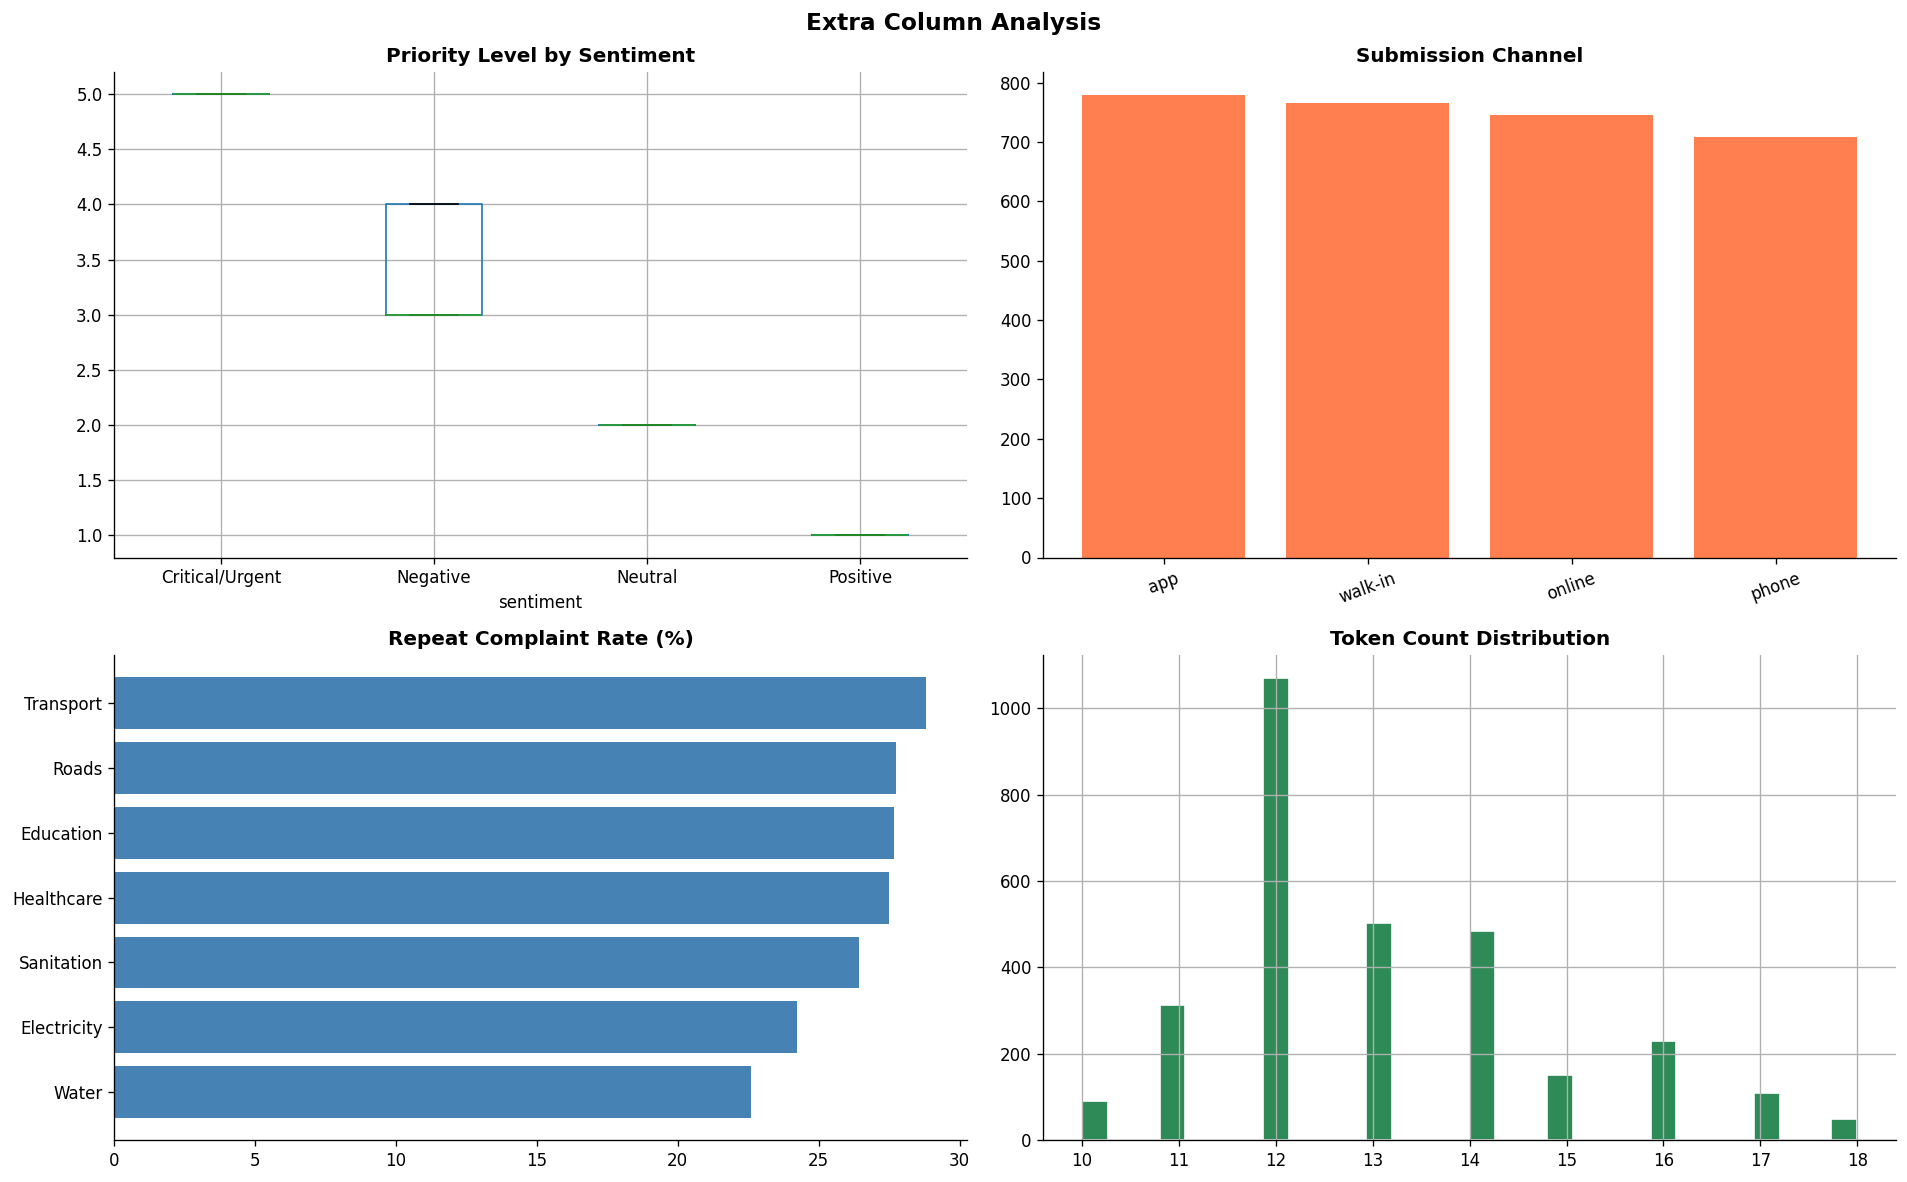

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if 'priority_level' in df_raw.columns:
    df_raw.boxplot(column='priority_level', by='sentiment', ax=axes[0,0])
    axes[0,0].set_title('Priority Level by Sentiment', fontweight='bold')

if 'submission_channel' in df_raw.columns:
    ch = df_raw['submission_channel'].value_counts()
    axes[0,1].bar(ch.index, ch.values, color='coral')
    axes[0,1].set_title('Submission Channel', fontweight='bold')
    axes[0,1].tick_params(axis='x', rotation=20)

if 'is_repeat_complaint' in df_raw.columns:
    repeat = df_raw.groupby('department')['is_repeat_complaint'].mean().sort_values()
    axes[1,0].barh(repeat.index, repeat.values*100, color='steelblue')
    axes[1,0].set_title('Repeat Complaint Rate (%)', fontweight='bold')
    
df_raw['token_count'].hist(ax=axes[1,1], bins=30, color='seagreen', edgecolor='white')
axes[1,1].set_title('Token Count Distribution', fontweight='bold')
plt.suptitle('Extra Column Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/04_extra_column_analysis.png', bbox_inches='tight')
plt.show()

In [48]:
df_raw.to_csv('data/preprocessed_grievances.csv', index=False)
print('Preprocessed data saved!')
print(f'Rows: {len(df_raw)}, Columns: {len(df_raw.columns)}')

Preprocessed data saved!
Rows: 3000, Columns: 16
